##PREDICCION DE CHURN EN TELECOMUNICACIONES





🔍 Introducción

La cancelación de clientes (churn) representa uno de los principales desafíos para las empresas de telecomunicaciones, ya que impacta directamente en los ingresos y en la estabilidad del negocio. Comprender por qué los clientes abandonan el servicio y poder anticipar ese comportamiento permite diseñar estrategias de retención más efectivas y basadas en evidencia.

En este proyecto se desarrolla un modelo de Machine Learning para predecir la probabilidad de cancelación de clientes utilizando información demográfica, contractual y de uso de servicios. El trabajo incluye el proceso completo de análisis predictivo: preparación y limpieza de datos, transformación de variables, entrenamiento de modelos de clasificación y evaluación de su rendimiento.

Además de la predicción, el objetivo central es identificar los factores que influyen en la decisión de cancelar el servicio, proporcionando información accionable para la toma de decisiones y el diseño de estrategias de fidelización.

##Presentacion de los datos

In [9]:
import pandas as pd
import json
import numpy as np


In [10]:
url = 'https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json'
df = pd.read_json(url)
df


,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
...,...,...,...,...,...,...
7262,9987-LUTYD,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
7263,9992-RRAMN,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
7264,9992-UJOEL,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
7265,9993-LHIEB,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Two year', 'PaperlessBilling': '..."


In [11]:
df.columns

Index(['customerID', 'Churn', 'customer', 'phone', 'internet', 'account'], dtype='object')

In [12]:
customer_df = pd.json_normalize(df['customer'])
customer_df.columns = 'customer_' + customer_df.columns

In [13]:
phone_df = pd.json_normalize(df['phone'])
phone_df.columns = 'phone_' + phone_df.columns

In [14]:
internet_df = pd.json_normalize(df['internet'])
internet_df.columns = 'internet_' + internet_df.columns

In [15]:
account_df = pd.json_normalize(df['account'])
account_df.columns = 'account_' + account_df.columns


In [16]:
df_final = pd.concat(
    [
        df[['customerID', 'Churn']],
        customer_df,
        phone_df,
        internet_df,
        account_df
    ],
    axis=1
)
df_final.head()


,customerID,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,...,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges.Monthly,account_Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [17]:
df_final['Churn'] = df_final['Churn'].map({'No': 0, 'Yes': 1})

In [18]:
df_final.dtypes

,0
customerID,object
Churn,float64
customer_gender,object
customer_SeniorCitizen,int64
customer_Partner,object
customer_Dependents,object
customer_tenure,int64
phone_PhoneService,object
phone_MultipleLines,object
internet_InternetService,object


In [19]:
df_final = df_final.drop('customerID', axis=1)

In [20]:
df_final.head()


,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,internet_OnlineSecurity,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges.Monthly,account_Charges.Total
0,0.0,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0.0,Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,1.0,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,1.0,Male,1,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,1.0,Female,1,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [21]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 20 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Churn                      7043 non-null   float64
 1   customer_gender            7267 non-null   object 
 2   customer_SeniorCitizen     7267 non-null   int64  
 3   customer_Partner           7267 non-null   object 
 4   customer_Dependents        7267 non-null   object 
 5   customer_tenure            7267 non-null   int64  
 6   phone_PhoneService         7267 non-null   object 
 7   phone_MultipleLines        7267 non-null   object 
 8   internet_InternetService   7267 non-null   object 
 9   internet_OnlineSecurity    7267 non-null   object 
 10  internet_OnlineBackup      7267 non-null   object 
 11  internet_DeviceProtection  7267 non-null   object 
 12  internet_TechSupport       7267 non-null   object 
 13  internet_StreamingTV       7267 non-null   objec

In [22]:
df_final['account_Charges.Total'] = pd.to_numeric(
    df_final['account_Charges.Total'],
    errors='coerce'
)

In [23]:
df_final = df_final.dropna(subset=['Churn', 'account_Charges.Total'])

In [24]:
df_final['Churn'] = df_final['Churn'].astype(int)

In [25]:
df_final.info()
df_final.isna().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7266
Data columns (total 20 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Churn                      7032 non-null   int64  
 1   customer_gender            7032 non-null   object 
 2   customer_SeniorCitizen     7032 non-null   int64  
 3   customer_Partner           7032 non-null   object 
 4   customer_Dependents        7032 non-null   object 
 5   customer_tenure            7032 non-null   int64  
 6   phone_PhoneService         7032 non-null   object 
 7   phone_MultipleLines        7032 non-null   object 
 8   internet_InternetService   7032 non-null   object 
 9   internet_OnlineSecurity    7032 non-null   object 
 10  internet_OnlineBackup      7032 non-null   object 
 11  internet_DeviceProtection  7032 non-null   object 
 12  internet_TechSupport       7032 non-null   object 
 13  internet_StreamingTV       7032 non-null   object 
 1

,0
Churn,0
customer_gender,0
customer_SeniorCitizen,0
customer_Partner,0
customer_Dependents,0
customer_tenure,0
phone_PhoneService,0
phone_MultipleLines,0
internet_InternetService,0
internet_OnlineSecurity,0


In [26]:
X = df_final.drop('Churn', axis=1)
y = df_final['Churn']

In [27]:
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

print("Numéricas:", list(num_cols))
print("Categóricas:", list(cat_cols))

Numéricas: ['customer_SeniorCitizen', 'customer_tenure', 'account_Charges.Monthly', 'account_Charges.Total']
Categóricas: ['customer_gender', 'customer_Partner', 'customer_Dependents', 'phone_PhoneService', 'phone_MultipleLines', 'internet_InternetService', 'internet_OnlineSecurity', 'internet_OnlineBackup', 'internet_DeviceProtection', 'internet_TechSupport', 'internet_StreamingTV', 'internet_StreamingMovies', 'account_Contract', 'account_PaperlessBilling', 'account_PaymentMethod']


In [28]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocesador = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first'), cat_cols)
    ]
)

In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

##Grafica de Churn según antigüedad del cliente

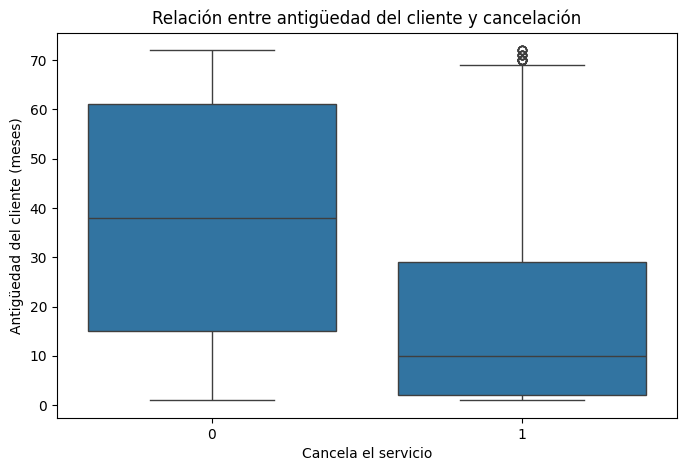

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.boxplot(x='Churn', y='customer_tenure', data=df_final)

plt.title("Relación entre antigüedad del cliente y cancelación")
plt.xlabel("Cancela el servicio")
plt.ylabel("Antigüedad del cliente (meses)")
plt.show()

👉 Los clientes que cancelan presentan MENOR antigüedad.
👉 La permanencia del cliente es el factor más fuerte de retención.

⭐ GRÁFICO MUY CLARO (contrato vs churn)

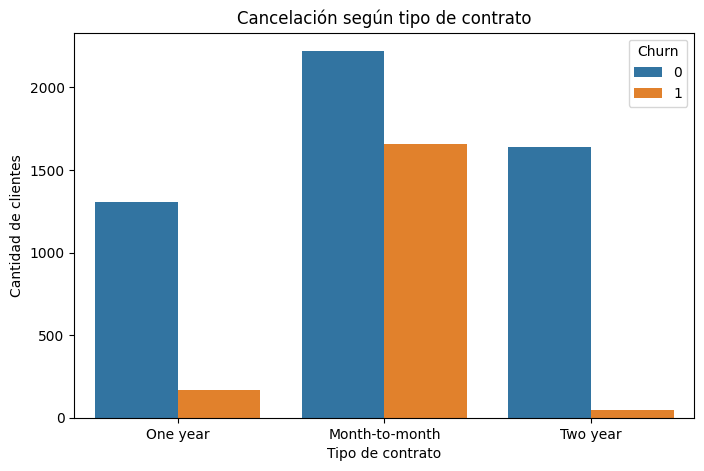

In [31]:
plt.figure(figsize=(8,5))
sns.countplot(x='account_Contract', hue='Churn', data=df_final)

plt.title("Cancelación según tipo de contrato")
plt.xlabel("Tipo de contrato")
plt.ylabel("Cantidad de clientes")
plt.show()

Interpretación:
👉 Contrato mensual = mayor churn
👉 Contratos largos = mayor retención

##Primer modelo Regresion Logistica

In [32]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

modelo_logistico = Pipeline(steps=[
    ('prep', preprocesador),
    ('modelo', LogisticRegression(max_iter=1000))
])

modelo_logistico.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['customer_SeniorCitizen', 'customer_tenure', 'account_Charges.Monthly',
       'account_Charges.Total'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  Index(['customer_gender', 'customer_Partner', 'customer_Dependents',
       'phone_PhoneService', 'phone_MultipleLines', 'internet_InternetService',
       'internet_OnlineSecurity', 'internet_OnlineBackup',
       'internet_DeviceProtection', 'internet_TechSupport',
       'internet_StreamingTV', 'internet_StreamingMovies', 'account_Contract',
       'account_PaperlessBilling', 'account_PaymentMethod'],
      dtype='object'))])),
                ('modelo', LogisticRegression(max_iter=1000))])

In [33]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

y_pred = modelo_logistico.predict(X_test)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1033
           1       0.65      0.53      0.58       374

    accuracy                           0.80      1407
   macro avg       0.75      0.71      0.73      1407
weighted avg       0.79      0.80      0.79      1407

[[927 106]
 [176 198]]
ROC AUC: 0.7133990091680428


🎯 Exactitud general

Accuracy = 0.80
→ 80% de predicciones correctas. Bien como modelo base.

🚨 Lo más importante en churn: detectar los que cancelan

Clase 1 = clientes que se van

Recall = 0.53
👉 El modelo detecta el 53% de los clientes que cancelan.
👉 Se escapa casi la mitad.


✔ 927 clientes fieles correctamente clasificados
✔ 198 cancelaciones detectadas correctamente
❌ 176 cancelaciones NO detectadas ← esto es lo crítico
❌ 106 falsas alarmas
⭐ ROC AUC = 0.71

Interpretación estándar:

0.50 → azar

0.70 → modelo aceptable

0.80 → buen modelo

0.90 → excelente

👉 Este modelo es aceptable y funcional.

##Grafico de Matriz de Confusion

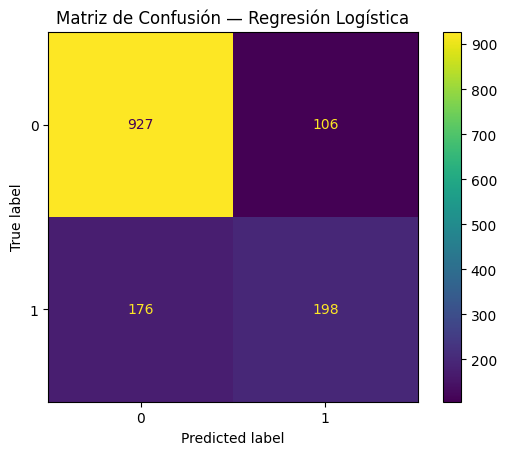

In [34]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Matriz de Confusión — Regresión Logística")
plt.show()

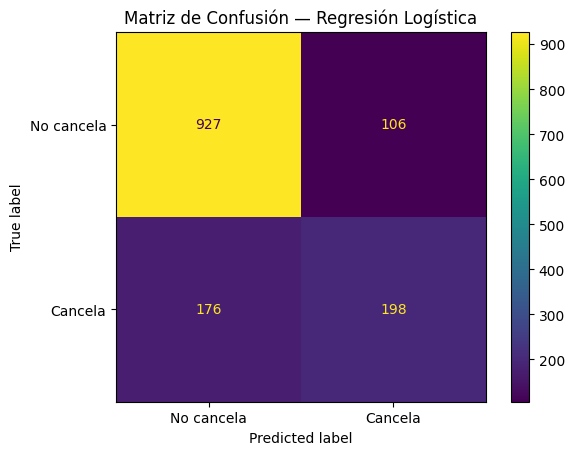

In [35]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No cancela", "Cancela"]
)
disp.plot()
plt.title("Matriz de Confusión — Regresión Logística")
plt.show()

🧾 Interpretación de la matriz de confusión — Regresión Logística

El modelo de regresión logística presenta un desempeño global del 80% de exactitud en el conjunto de prueba.
Al analizar la matriz de confusión se observa:

927 clientes que no cancelan fueron correctamente clasificados.

198 clientes que cancelaron fueron correctamente detectados por el modelo.

176 clientes que cancelaron no fueron identificados, siendo clasificados erróneamente como clientes que permanecen.

106 clientes fueron clasificados como cancelación cuando en realidad no cancelaron.

Esto indica que el modelo tiene buen desempeño para identificar clientes que permanecen en la empresa, pero presenta limitaciones para detectar todos los casos de cancelación.

El recall de la clase de cancelación es 0.53, lo que significa que el modelo identifica aproximadamente el 53% de los clientes que abandonan el servicio. En problemas de churn esta métrica es especialmente relevante, ya que el objetivo principal es detectar clientes con riesgo de cancelación para aplicar estrategias de retención.

El valor de ROC AUC = 0.71 indica una capacidad de discriminación aceptable entre clientes que cancelan y los que no.

En conclusión, la regresión logística funciona como un modelo base adecuado, aunque existe margen de mejora en la detección de clientes que cancelan el servicio.

##Segundo modelo Random Forest

In [36]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

modelo_rf = Pipeline(steps=[
    ('prep', preprocesador),
    ('modelo', RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ))
])

modelo_rf.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['customer_SeniorCitizen', 'customer_tenure', 'account_Charges.Monthly',
       'account_Charges.Total'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  Index(['customer_gender', 'customer_Partner', 'customer_Dependents',
       'phone_PhoneService', 'phone_MultipleLines', 'internet_InternetService',
       'internet_OnlineSecurity', 'internet_OnlineBackup',
       'internet_DeviceProtection', 'internet_TechSupport',
       'internet_StreamingTV', 'internet_StreamingMovies', 'account_Contract',
       'account_PaperlessBilling', 'account_PaymentMethod'],
      dtype='object'))])),
                ('modelo',
                 RandomForestClassifier(n_estimators=200, random_state=42))])

In [37]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

y_pred_rf = modelo_rf.predict(X_test)

print(classification_report(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))
print("ROC AUC:", roc_auc_score(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.64      0.48      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.70      1407
weighted avg       0.78      0.79      0.78      1407

[[931 102]
 [195 179]]
ROC AUC: 0.6899340480713978


##Grafico de Matriz de confusión

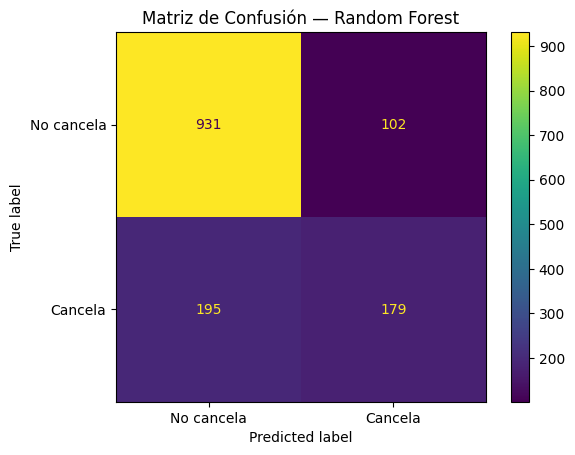

In [38]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm_rf = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["No cancela", "Cancela"]
)
disp.plot()

plt.title("Matriz de Confusión — Random Forest")
plt.show()

La matriz de confusión muestra que el modelo RANDOM FOREST identifica correctamente a la mayoría de los clientes que permanecen en la compañía, pero presenta dificultades para detectar a los clientes que cancelan el servicio. En particular, el recall para la clase churn es de 0.48, lo que indica que más de la mitad de las cancelaciones reales no son anticipadas. Desde el punto de vista del negocio, esto implica oportunidades perdidas de retención. El valor ROC AUC de 0.69 sugiere una capacidad de discriminación aceptable, aunque con margen de mejora mediante técnicas de balanceo de clases o ajuste de hiperparámetros.

👉 El modelo es bueno para identificar clientes estables, pero no es suficientemente sensible para detectar cancelaciones.
👉 Desde el punto de vista empresarial, los falsos negativos (195 clientes que se fueron y no se predijeron) representan oportunidades perdidas de retención.

##Importancia de variables

In [39]:
import pandas as pd

# obtener nombres de columnas transformadas
feature_names = modelo_rf.named_steps['prep'].get_feature_names_out()

importancias = modelo_rf.named_steps['modelo'].feature_importances_

df_importancia = pd.DataFrame({
    'Variable': feature_names,
    'Importancia': importancias
}).sort_values(by='Importancia', ascending=False)

df_importancia.head(10)

,Variable,Importancia
3,num__account_Charges.Total,0.194086
2,num__account_Charges.Monthly,0.169853
1,num__customer_tenure,0.169067
28,cat__account_PaymentMethod_Electronic check,0.038835
10,cat__internet_InternetService_Fiber optic,0.037989
25,cat__account_Contract_Two year,0.031590
4,cat__customer_gender_Male,0.028886
13,cat__internet_OnlineSecurity_Yes,0.026610
26,cat__account_PaperlessBilling_Yes,0.026012
24,cat__account_Contract_One year,0.023712


🌲 Importancia (Random Forest)

👉 Es la contribución relativa de cada variable en las decisiones del modelo.

Indica:
✔ qué variables usa más el modelo
✔ cuáles ayudan más a separar clases
✔ relevancia comparativa entre variables

PERO:
❌ no indica dirección del efecto
❌ no dice si aumenta o reduce churn

💡 Responde a la pregunta:
¿Qué tan relevante es esta variable para predecir?

🎯 Diferencia en una frase clara

Impacto = dirección + efecto
Importancia = relevancia para predecir

##Comparacion de metricas entre modelos

In [ ]:
| Métrica                | Regresión Logística | Random Forest |
|------------------------|--------------------|--------------|
| Accuracy               | 0.80               | 0.79         |
| Recall churn (clase 1) | 0.53               | 0.48         |
| ROC AUC                | 0.71               | 0.69         |

In [41]:
import pandas as pd

tabla_metricas = pd.DataFrame({
    "Métrica": ["Accuracy", "Recall churn (clase 1)", "ROC AUC"],
    "Regresión Logística": [0.80, 0.53, 0.71],
    "Random Forest": [0.79, 0.48, 0.69]
})

tabla_metricas

,Métrica,Regresión Logística,Random Forest
0,Accuracy,0.80,0.79
1,Recall churn (clase 1),0.53,0.48
2,ROC AUC,0.71,0.69


🧠 Conclusión técnica

👉 La regresión logística tiene mejor capacidad para detectar cancelaciones.
👉 Random Forest clasifica bien a los clientes que permanecen, pero pierde más cancelaciones.
👉 Por lo tanto, el modelo logístico es el mejor para este problema.

🧾  — Comparación de modelos

El modelo Random Forest fue entrenado para comparar su rendimiento con la regresión logística. Si bien presentó una exactitud similar, su capacidad para detectar clientes que cancelan fue menor. El recall de la clase de cancelación fue de 0.48, inferior al obtenido por la regresión logística (0.53).

Asimismo, el valor de ROC AUC del Random Forest fue 0.69, también por debajo del modelo logístico (0.71). Esto indica que el modelo logístico posee una mejor capacidad de discriminación entre clientes que cancelan y los que permanecen.

En consecuencia, la regresión logística se selecciona como el modelo más adecuado para predecir la cancelación de clientes en este conjunto de datos y
dado que el objetivo del problema es detectar cancelaciones, se prioriza el recall de la clase churn por sobre la exactitud global.

🧠 Importancia de variables (modelo logístico)

In [42]:
import pandas as pd

feature_names = modelo_logistico.named_steps['prep'].get_feature_names_out()
coeficientes = modelo_logistico.named_steps['modelo'].coef_[0]

df_coef = pd.DataFrame({
    'Variable': feature_names,
    'Impacto': coeficientes
}).sort_values(by='Impacto', ascending=False)

df_coef.head(10)

,Variable,Impacto
10,cat__internet_InternetService_Fiber optic,0.935909
3,num__account_Charges.Total,0.616836
26,cat__account_PaperlessBilling_Yes,0.372177
28,cat__account_PaymentMethod_Electronic check,0.354661
21,cat__internet_StreamingTV_Yes,0.346440
9,cat__phone_MultipleLines_Yes,0.250721
23,cat__internet_StreamingMovies_Yes,0.205771
0,num__customer_SeniorCitizen,0.094776
17,cat__internet_DeviceProtection_Yes,0.024759
29,cat__account_PaymentMethod_Mailed check,-0.005055


In [ ]:
df_coef.tail(10)

Los coeficientes del modelo de regresión logística representan la influencia de cada variable en la probabilidad de cancelación. Los valores negativos indican factores asociados a menor riesgo de churn, mientras que los valores positivos indican mayor probabilidad de cancelación.
Los coeficientes representan el cambio en el logaritmo de las probabilidades de cancelación ante variaciones en las variables explicativas. En términos prácticos, el signo indica la dirección del efecto y el valor absoluto refleja la intensidad de la influencia en la predicción.

🧠 Impacto (regresión logística)

👉 Es el coeficiente del modelo.

Indica:
✔ si la variable aumenta o reduce el churn
✔ la dirección del efecto
✔ la fuerza del efecto (según el valor absoluto)

Interpretación:

negativo → reduce la cancelación

positivo → aumenta la cancelación

valor grande → efecto fuerte

💡 Responde a la pregunta:
¿Cómo influye esta variable en el resultado?

Ejemplo:
customer_tenure = -1.32
→ más antigüedad = menor churn

🎯 Diferencia en una frase clara

-Impacto = dirección + efecto


---


-Importancia = relevancia para predecir





## Factores que REDUCEN la cancelación
🏆 PERMANENCIA DEL CLIENTE (el más fuerte)

customer_tenure (–1.32)
👉 Cuanto MAS tiempo lleva el cliente, MENOS probabilidad de cancelar.
💡 Clientes nuevos = mayor riesgo.

📄 Tipo de contrato

Contrato de 2 años (–1.27)
Contrato de 1 año (–0.70)
👉 Los contratos largos reducen muchísimo el churn.
💡 El contrato mensual se asocia con el mayor riesgo de cancelación.

🛠 Servicios de soporte y seguridad

TechSupport = Yes (–0.41)
OnlineSecurity = Yes (–0.33)
👉 Los servicios de valor agregado AUMENTAN la retención.
💡 Clientes más “integrados” al ecosistema → se van menos.

📞 Servicio telefónico activo

PhoneService = Yes (–0.44)
👉 Tener MAS servicios contratados REDUCE cancelación.

💰 Cargos mensuales (dato interesante)

Monthly Charges (–0.24)
👉 En este modelo, clientes con mayor gasto mensual tienden a permanecer.
💡 Probablemente perciben mayor valor del servicio.

## Factores de churn

El análisis de los coeficientes del modelo de regresión logística permitió identificar los principales factores asociados a la permanencia de los clientes. La antigüedad del cliente (tenure) resultó ser el factor más influyente en la reducción de la cancelación, evidenciando que los clientes con mayor tiempo en la empresa presentan menor probabilidad de abandono.

Asimismo, los contratos de largo plazo (especialmente los contratos de dos años) disminuyen significativamente la probabilidad de cancelación en comparación con los contratos mensuales.

La contratación de servicios adicionales como soporte técnico y seguridad en línea también se asocia con una mayor retención, lo que sugiere que los clientes que utilizan más servicios presentan mayor compromiso con la empresa.

##En conjunto, estos resultados indican que la permanencia del cliente se relaciona fuertemente con el nivel de vinculación contractual y el uso de servicios complementarios.

##Resumen ejecutivo

El presente trabajo tuvo como objetivo desarrollar un modelo predictivo para identificar clientes con riesgo de cancelación del servicio (churn) en una empresa de telecomunicaciones. Se realizó un proceso completo de preparación de datos, incluyendo limpieza, codificación de variables categóricas y normalización de variables numéricas.

Se entrenaron y evaluaron DOS modelos de clasificación: REGRESION LOGISTICA y RANDOM FOREST. La evaluación se realizó mediante métricas de desempeño como accuracy, recall, F1-score y ROC AUC. Los resultados indicaron que la regresión logística presentó mejor capacidad para detectar clientes que cancelan el servicio, por lo que fue seleccionada como modelo final.

El análisis de los coeficientes del modelo permitió identificar factores clave asociados al churn. La antigüedad del cliente y los contratos de largo plazo reducen significativamente la probabilidad de cancelación, mientras que los clientes nuevos y con contratos mensuales presentan mayor riesgo.

Estos hallazgos permiten proponer estrategias de retención orientadas a clientes con mayor probabilidad de abandono, contribuyendo a la toma de decisiones basada en datos.

##Aplicación práctica del modelo predictivo

🔮 Predicción para un cliente hipotético

Antes de presentar las conclusiones estratégicas, se aplica el modelo entrenado a un cliente simulado con el objetivo de ilustrar su funcionamiento en un caso individual y mostrar su utilidad práctica en escenarios reales de decisión.

Para comprender cómo el modelo toma decisiones individuales, puede considerarse un CLIENTE HIPOTETICO con determinadas características. El modelo calcula una probabilidad de cancelación y, en función de un umbral de decisión (por ejemplo 0.5), clasifica al cliente como churn o no churn. Este proceso permite interpretar cómo las características del cliente influyen en la predicción final, incluso sin necesidad de evaluar un caso real específico.

# ===== Cliente hipotético =====

In [43]:

import pandas as pd

cliente_nuevo = pd.DataFrame({
    'customer_gender': ['Female'],
    'customer_SeniorCitizen': [0],
    'customer_Partner': ['No'],
    'customer_Dependents': ['No'],
    'customer_tenure': [2],  # cliente nuevo
    'phone_PhoneService': ['Yes'],
    'phone_MultipleLines': ['No'],
    'internet_InternetService': ['Fiber optic'],
    'internet_OnlineSecurity': ['No'],
    'internet_OnlineBackup': ['No'],
    'internet_DeviceProtection': ['No'],
    'internet_TechSupport': ['No'],
    'internet_StreamingTV': ['No'],
    'internet_StreamingMovies': ['No'],
    'account_Contract': ['Month-to-month'],
    'account_PaperlessBilling': ['Yes'],
    'account_PaymentMethod': ['Electronic check'],
    'account_Charges.Monthly': [70],
    'account_Charges.Total': [140]
})

# ===== Predicción =====
prob_churn = modelo_logistico.predict_proba(cliente_nuevo)[0][1]
prediccion = modelo_logistico.predict(cliente_nuevo)[0]

print("Probabilidad de cancelación:", round(prob_churn, 3))
print("Clasificación del modelo:", "Cancela" if prediccion == 1 else "Permanece")

Probabilidad de cancelación: 0.704
Clasificación del modelo: Cancela


El modelo estima una probabilidad elevada de cancelación para un cliente nuevo con contrato mensual y sin servicios adicionales. Este perfil coincide con los principales factores de riesgo identificados en el análisis, por lo que debería ser priorizado en estrategias de retención temprana.

🎯 CONCLUSION ESTRATEGICA:

El modelo predictivo permitió identificar patrones claros asociados a la cancelación de clientes. Los resultados muestran que los clientes con MENOR antigüedad, contratos mensuales y menor uso de servicios adicionales presentan MAYOR riesgo de abandono.

Desde una perspectiva estratégica, la empresa debería enfocar sus esfuerzos de retención en clientes nuevos y en aquellos con contratos de corto plazo, promoviendo la migración hacia contratos de mayor duración. Asimismo, la promoción de servicios de valor agregado como soporte técnico y seguridad en línea podría contribuir a fortalecer la fidelización de los clientes.

La implementación de estrategias de retención focalizadas en el perfil de riesgo identificado podría reducir significativamente la tasa de cancelación.

🚀 INSIGHT DE NEGOCIO

Los clientes nuevos presentan el mayor riesgo de cancelación.

Los contratos mensuales concentran la mayor proporción de churn.

La antigüedad del cliente es el factor más fuerte de retención.

Los clientes con servicios adicionales (soporte técnico, seguridad) cancelan menos.

👉 El churn está fuertemente asociado al nivel de vinculación del cliente con el servicio.






🎯 CONCLUSION FINAL

El modelo predictivo permite identificar perfiles de alto riesgo de cancelación y revela que la permanencia del cliente, el tipo de contrato y el uso de servicios adicionales son factores clave de retención. En base a estos hallazgos, estrategias enfocadas en clientes nuevos, incentivos para contratos de largo plazo y promoción de servicios de valor agregado pueden contribuir significativamente a reducir la tasa de cancelación.

##Recomendaciones estratégicas basadas en el modelo

A partir de los resultados obtenidos, se proponen las siguientes acciones para reducir la cancelación de clientes:

🎯 1. Estrategias de retención para clientes nuevos

   El modelo indica que los clientes con MENOR antigüedad presentan MAYOR probabilidad de cancelación.
   Acciones recomendadas:

Programas de bienvenida y acompañamiento durante los primeros meses

Beneficios temporales por permanencia (descuentos, upgrades)

Contacto proactivo ante señales de bajo uso del servicio

📄 2. Incentivar contratos de largo plazo

Los contratos mensuales están fuertemente asociados a mayor churn.
Acciones recomendadas:

Ofrecer descuentos o beneficios por migración a contratos anuales o bianuales

Bonificaciones por renovación anticipada

Paquetes promocionales para fidelización

🛠 3. Promoción de servicios de valor agregado

Servicios como soporte técnico y seguridad en línea se asocian con mayor retención.
Acciones recomendadas:

Ofrecer estos servicios como parte de paquetes integrados

Promociones para clientes con bajo nivel de servicios contratados

Comunicación del valor agregado del ecosistema de servicios

🤝 4. Segmentación de clientes en riesgo

El modelo permite identificar perfiles con alta probabilidad de cancelación.
Acciones recomendadas:

Campañas de retención focalizadas

Ofertas personalizadas según perfil de cliente

Seguimiento PREVENTIVO de clientes con alto riesgo



🎯 CIERRE ESTRATEGICO BREVE

La implementación de estrategias diferenciadas según el perfil de riesgo del cliente puede mejorar significativamente la retención, optimizar recursos comerciales y fortalecer la relación a largo plazo con los usuarios.